# Deep Learning Assignment 2
#### By: Logan Justin Gunawan (S4096363)

## The Task:

I have built the company Litmus pty with my friend. Litmus pty runs studies on the deconstruction and analysis of memes and how they use certain psychological techniques to elicit a response from a viewer. Previously, we have done all of this analysis by hand, however, we would like to expand our reach by creating a model which automatically detects, what psychological techniques a meme uses, as well as what part of the meme specifically uses each technique. We have 22 possible techniques (listed under 'techniques_list_task3.txt') to choose from, but a meme can also utilise none of those techniques. Additionally, 2 of the techniques are not applicable for this task as they are only used for Image-based memes, whereas we focus on the extracted text of a meme. We will remove the 2 inapplicable techniques, "Transfer" and "Appeal to (Strong) emotions" from our list of techniques.

## Loading Libraries

In [51]:
import torch
import torch.nn as nn   
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
import re, os, math
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## The Data

I first load the data which is provided to me. The data has already been pre-split into a train, dev and test sets so no further splitting is required.

In [53]:
LABELS = [  "Appeal to authority",
            "Appeal to fear/prejudice",
            "Black-and-white Fallacy/Dictatorship",
            "Causal Oversimplification",
            "Doubt",
            "Exaggeration/Minimisation",
            "Flag-waving",
            "Glittering generalities (Virtue)",
            "Loaded Language",
            "Misrepresentation of Someone's Position (Straw Man)",
            "Name calling/Labeling",
            "Obfuscation, Intentional vagueness, Confusion",
            "Presenting Irrelevant Data (Red Herring)",
            "Reductio ad hitlerum",
            "Repetition",
            "Slogans",
            "Smears",
            "Thought-terminating cliché",
            "Whataboutism",
            "Bandwagon"
]

dev_set_task1 = pd.read_json("data_2026_A2/data/dev_set_task1.txt")
dev_set_task2 = pd.read_json("data_2026_A2/data/dev_set_task2.txt")
test_set_task1 = pd.read_json("data_2026_A2/data/test_set_task1.txt")
test_set_task2 = pd.read_json("data_2026_A2/data/test_set_task2.txt")
train_set_task1 = pd.read_json("data_2026_A2/data/training_set_task1.txt")
train_set_task2 = pd.read_json("data_2026_A2/data/training_set_task2.txt")

all_set_task1 = pd.concat([dev_set_task1, train_set_task1, test_set_task1], 
                          axis = 0)

print(f"Task 1 Train Dataset Length: {len(train_set_task1)}")
print(f"Task 2 Train Dataset Length: {len(train_set_task2)}")
print(f"Task 1 Test Dataset Length: {len(test_set_task1)}")
print(f"Task 2 Test Dataset Length: {len(test_set_task2)}")
print(f"Task 1 Dev Dataset Length: {len(dev_set_task1)}")
print(f"Task 2 Dev Dataset Length: {len(dev_set_task2)}")

all_set_task1.head()

Task 1 Train Dataset Length: 688
Task 2 Train Dataset Length: 688
Task 1 Test Dataset Length: 200
Task 2 Test Dataset Length: 200
Task 1 Dev Dataset Length: 63
Task 2 Dev Dataset Length: 63


,id,labels,text
0,62_batch_2,[],"*President* Biden?\n\nPlease, no.\n"
1,111_batch_2,"[Loaded Language, Name calling/Labeling]","JOE VERSUS THE VOLCANIC KREMLIN DON\n\n""WILL ..."
2,167_batch_2,[],ANTI-VAXXERS BE LIKE... \n\nHANG ON A SEC - JU...
3,93_batch_2,[],VIRUS BINGO\nFREE 32 SPACE\n
4,153_batch_2,"[Exaggeration/Minimisation, Loaded Language, N...",Never thought l'd die fighting IRRESPONSIBLY R...


I can then view the distribution of each label, to see how common they are within the dataset. The following pie chart reveals the most commonly used labels being "Loaded Language", "Name Calling / Labeling" and "Smears" which occupy a large portion of the data, whereas minority labels such as Red Herring, Obfuscation, etc barely appear. I will need to take into consideration these label instability later when creating my models.

Text(0.5, 1.0, 'Label Distribution')

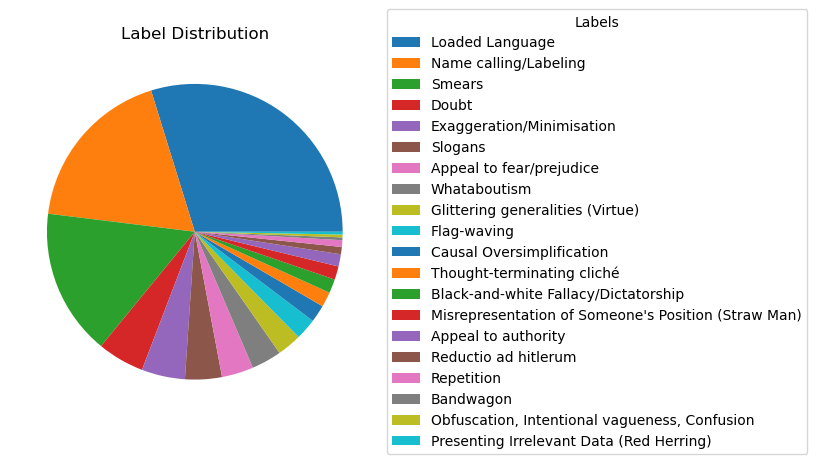

In [54]:
label_counts = Counter(
    label
    for labels in all_set_task1["labels"]
    for label in labels
)

label_counts_df = pd.DataFrame(label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)

wedges, _ = plt.pie(label_counts_df["Count"].values)

plt.legend(wedges,
           label_counts_df["Label"].values,
           title="Labels",
           bbox_to_anchor=(1, 0.5),
           loc="center left")

plt.title("Label Distribution")

In [55]:
label_counts.most_common()

[('Loaded Language', 489),
 ('Name calling/Labeling', 300),
 ('Smears', 263),
 ('Doubt', 84),
 ('Exaggeration/Minimisation', 78),
 ('Slogans', 66),
 ('Appeal to fear/prejudice', 57),
 ('Whataboutism', 54),
 ('Glittering generalities (Virtue)', 44),
 ('Flag-waving', 38),
 ('Causal Oversimplification', 31),
 ('Thought-terminating cliché', 27),
 ('Black-and-white Fallacy/Dictatorship', 25),
 ("Misrepresentation of Someone's Position (Straw Man)", 24),
 ('Appeal to authority', 22),
 ('Reductio ad hitlerum', 13),
 ('Repetition', 12),
 ('Bandwagon', 5),
 ('Obfuscation, Intentional vagueness, Confusion', 5),
 ('Presenting Irrelevant Data (Red Herring)', 5)]

### Label Encoding

In [56]:
label_to_idx = {label : i for i, label in enumerate(LABELS)}

def encode_labels(labels):
    encoded = [0] * len(LABELS)
    for label in labels:
        encoded[label_to_idx[label]] = 1

    return torch.tensor(encoded, dtype=torch.float32)

train_set_task1["label_encoded"] = train_set_task1["labels"].apply(encode_labels)
test_set_task1["label_encoded"] = test_set_task1["labels"].apply(encode_labels)
dev_set_task1["label_encoded"] = dev_set_task1["labels"].apply(encode_labels)

train_set_task1.head()

,id,labels,text,label_encoded
0,128,[Black-and-white Fallacy/Dictatorship],THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n,"[tensor(0.), tensor(0.), tensor(1.), tensor(0...."
1,189,[],This is not an accident!,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."
2,96,"[Loaded Language, Name calling/Labeling, Sloga...",SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."
3,154,"[Causal Oversimplification, Loaded Language, N...",PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...,"[tensor(0.), tensor(0.), tensor(0.), tensor(1...."
4,15,[],WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."


## Utilities

Here I create some general utility functions which will be used across my tasks. 

#### Generating Label Weights

I create a label weight map such that I can use it later in my loss calculations in order to solve the problem of label inequality. For my baseline, I use inverse frequency class weighting, it gives values with low label counts higher weights, such that the model should prioritize labelling minority labels correctly. 

Viewing the generated label weights for task 1, I notice several potential issues, which I will explain and improve on further on in model experiments.

In [57]:
# Generating Label Weights
task1_label_counts = Counter(label
                             for labels in train_set_task1["labels"]
                             for label in labels)

total = len(train_set_task1)
total_labels = len(LABELS)

task1_label_weights = torch.tensor(
    [
    (total - task1_label_counts[label]) / (task1_label_counts[label])
    if task1_label_counts[label] > 0 else 1
    for label in LABELS
    ]
).to(device)

print('Label weights for Task 1:')
for i, label in enumerate(LABELS):
    print(
        f"{label:<55} "
        f"count={task1_label_counts[label]:>3} "
        f"weight={task1_label_weights[i].item():.2f}"
    )

"""
task1_label_counts_df = pd.DataFrame(task1_label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)

wedges, _ = plt.pie(task1_label_counts_df["Count"].values)

plt.legend(wedges,
           task1_label_counts_df["Label"].values,
           title="Labels",
           bbox_to_anchor=(1, 0.5),
           loc="center left")

plt.title("Label Distribution")
"""

Label weights for Task 1:
Appeal to authority                                     count= 13 weight=51.92
Appeal to fear/prejudice                                count= 43 weight=15.00
Black-and-white Fallacy/Dictatorship                    count= 18 weight=37.22
Causal Oversimplification                               count= 27 weight=24.48
Doubt                                                   count= 48 weight=13.33
Exaggeration/Minimisation                               count= 52 weight=12.23
Flag-waving                                             count= 27 weight=24.48
Glittering generalities (Virtue)                        count= 32 weight=20.50
Loaded Language                                         count=358 weight=0.92
Misrepresentation of Someone's Position (Straw Man)     count= 20 weight=33.40
Name calling/Labeling                                   count=218 weight=2.16
Obfuscation, Intentional vagueness, Confusion           count=  4 weight=171.00
Presenting Irrelevant Data 

'\ntask1_label_counts_df = pd.DataFrame(task1_label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)\n\nwedges, _ = plt.pie(task1_label_counts_df["Count"].values)\n\nplt.legend(wedges,\n           task1_label_counts_df["Label"].values,\n           title="Labels",\n           bbox_to_anchor=(1, 0.5),\n           loc="center left")\n\nplt.title("Label Distribution")\n'

#### Training Utilities (Adapted from Labs)

Here I adapt some utility functions straight from the labs so that they will fit the multi-label classification problem that we have. 

In [58]:
def train_one_epoch(model, loader, optimizer, criterion, tokenizer_mode=False):
    model.train()
    total_loss, total = 0.0, 0
    for batch in loader:
        if tokenizer_mode:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=y)
            loss = outputs.loss
            logits = outputs.logits
        else:
            x, y, lengths = batch
            x, y = x.to(device), y.to(device)
            logits = model(x, lengths)
            loss = criterion(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * y.numel()
        total += y.numel()
    return total_loss / total


def evaluate_model(model, loader, criterion, tokenizer_mode=False):
    model.eval()
    total_loss, total = 0.0, 0
    with torch.inference_mode():
        for batch in loader:
            if tokenizer_mode:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                y = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=y)
                loss = outputs.loss
                logits = outputs.logits
            else:
                x, y, lengths = batch
                x, y = x.to(device), y.to(device)
                logits = model(x, lengths)
                loss = criterion(logits, y)
            
            total_loss += loss.item() * y.numel()
            total += y.numel()
    return total_loss / total


def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=10, name='Model', tokenizer_mode=False):
    history = {'train_loss': [], 'val_loss': []}
    best_model = None
    best_loss = 999999
    
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, tokenizer_mode)
        val_loss = evaluate_model(model, val_loader, criterion, tokenizer_mode)
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f'  [{name}] Epoch {epoch+1}/{epochs} — '
                  f'Train: {train_loss:.4f} | Val: {val_loss:.4f}')
    
    model.load_state_dict(best_model)
    
    return history


def plot_experiments(results, show_train=True, show_val=True):
    fig, ax = plt.subplots()
    for name, hist in results.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        if show_train:
            ax.plot(epochs, hist['train_loss'], label=f'{name} (Train)', marker='o', markersize=3)
        if show_val:
            ax.plot(epochs, hist['val_loss'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
    
    ax.set_xlabel('Epoch'); ax.set_ylabel("Loss"); ax.set_title("Loss")
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

I also create a custom evaluation function get_evaluation() which I will be using to evaluate my task 1 models. It uses creates a classification report of the model's predictions vs ground truth giving per-class precision, recall, f1-score and accuracy counts, as well as overall micro and macro averaged values for those values. Then it creates a multi-label confusion matrix and returns both of them as a tuple. This will help get better insight at how the model is predicting on each label.

In [59]:
def get_evaluation(model, val_loader, name, prob_threshold = 0.5):
    model.eval()
    val_predictions = []
    val_true = []
    
    with torch.inference_mode():
        for batch in val_loader:
            x, y, lengths = batch
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probabilities = torch.sigmoid(logits)
            prediction = (probabilities >= prob_threshold).float()
            
            val_predictions.append(prediction)
            val_true.append(y)
    
    val_predictions = torch.cat(val_predictions, dim=0).cpu().numpy()
    val_true = torch.cat(val_true, dim=0).cpu().numpy()
    
    matrix = multilabel_confusion_matrix(val_true, 
                                         val_predictions)
    
    report = classification_report(val_true, 
                                    val_predictions, 
                                    target_names=LABELS, 
                                    output_dict = True)
    
    fig, ax = plt.subplots(4, 5, figsize = (10,10))
    accuracies = []
    for i, label in enumerate(LABELS):
        current_ax = ax[i//5][i%5]
        current_row = report[label]
        
        cf = ConfusionMatrixDisplay(matrix[i])
        cf.plot(ax = current_ax,cmap='Blues', colorbar = False)
        current_ax.set_title(label[:20], fontsize=10)
        
        tn, fp, fn, tp = matrix[i].ravel()
        accuracy = (tp + tn) / (tp + tn + fn + fp) if (tp + tn + fn + fp) > 0 else 0
        current_row["accuracy"] = accuracy
        accuracies.append(accuracy)
    
    fig.suptitle(name)
    fig.subplots_adjust(wspace = 0.5, hspace = 1)
    
    return fig, report, accuracy


def view_report(report):
    print(f"{'':>23}{'precision':>12}{'recall':>12}{'f1-score':>12}{'support':>12}{'accuracy':>12}")

    for label, values in report.items():
        if isinstance(values, dict):
            print(
                f"{label[:20]:<23}"
                f"{values.get("precision", 0):>12.4f}"
                f"{values.get("recall", 0):>12.4f}"
                f"{values.get("f1-score", 0):>12.4f}"
                f"{values.get("support", 0):>12.0f}"
                f"{values.get("accuracy", 0):>12.4f}"
            )

#### Positional Encoder (Taken from Labs)

In [60]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

#### Tokenizer

In [61]:
def simple_tokenize(text : str):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

print(simple_tokenize("THOSE LIBERALS HATE ME\n\nIT'S BECAUSE I'M BLACK ISN'T IT ?\n"))

['those', 'liberals', 'hate', 'me', 'its', 'because', 'im', 'black', 'isnt', 'it']


# Task 1: Building the Detector

For Task 1, I will need to simply create a model that can predict the employed techniques of a single meme. I will first create a baseline model using LSTM, try to improve it via a sleugh of experiments, such as modifying class weights, using pretrained dense embeddings, etc. Then I will create several other models, such as using a self-trained or pre-trained transformer and compare all of the model's performances.  


## Preparing the Dataset

### Building Vocabulary

In [62]:
# Build vocabulary
all_train_tokens = [simple_tokenize(t) for t in train_set_task1["text"]]
word_counts = Counter()
for tokens in all_train_tokens:
    word_counts.update(tokens)

PAD_IDX, UNK_IDX = 0, 1
word_to_idx = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
idx = 2
for word, count in word_counts.most_common():
    if count >= 5:
        word_to_idx[word] = idx
        idx += 1
    else:
        break

VOCAB_SIZE = len(word_to_idx)
MAX_LEN = 64
print(f'Vocabulary: {VOCAB_SIZE}, Max length: {MAX_LEN}')

print(f"Max: {len(max(all_train_tokens, key = len))}")

Vocabulary: 407, Max length: 64
Max: 72


In [63]:
# Dataset class (same as Week 7)
class TextDataset(Dataset):
    def __init__(self, texts, labels, word_to_idx, tokenizer = simple_tokenize, max_len=MAX_LEN):
        self.labels = labels
        self.sequences, self.lengths = [], []
        for text in texts:
            tokens = tokenizer(text)
            indices = [word_to_idx.get(t, UNK_IDX) for t in tokens[:max_len]]
            self.lengths.append(len(indices))
            indices += [PAD_IDX] * (max_len - len(indices))
            self.sequences.append(indices)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float32),
            self.lengths[idx],
        )

train_ds = TextDataset(train_set_task1["text"], train_set_task1["label_encoded"], word_to_idx)
val_ds = TextDataset(dev_set_task1["text"], dev_set_task1["label_encoded"], word_to_idx)
test_ds = TextDataset(test_set_task1["text"], test_set_task1["label_encoded"], word_to_idx)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=True)

## Models

### BASELINE MODEL (LSTM)

For my baseline model, I will be using a simple RNN, specifically LSTM. RNNs typically have many drawbacks relating to vanishing gradients due to the influence of earlier tokens being overwritten as time goes on. LSTM does aim to solve this problem by using several gates, however, they will still eventually fall to the same drawback. For this task specifically, however, the lengths of a meme should intuitively, not be too long. This is backed up by the boxplot of lengths of our memes below, which backs up that the median length of a meme is only ~15 tokens, which should theoretically be short enough to not fall to the vanishing gradient problem. It will most likely struggle on the longer memes, especially the high outliers of lengths >50. However, we can fix that in the later experiments.

{'whiskers': [<matplotlib.lines.Line2D at 0x15b9dbb0550>,
 'caps': [<matplotlib.lines.Line2D at 0x15b9dbb07d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x15b9dbb0410>],
 'medians': [<matplotlib.lines.Line2D at 0x15b9dbb0a50>],
 'fliers': [<matplotlib.lines.Line2D at 0x15b9dbb0b90>],
 'means': []}

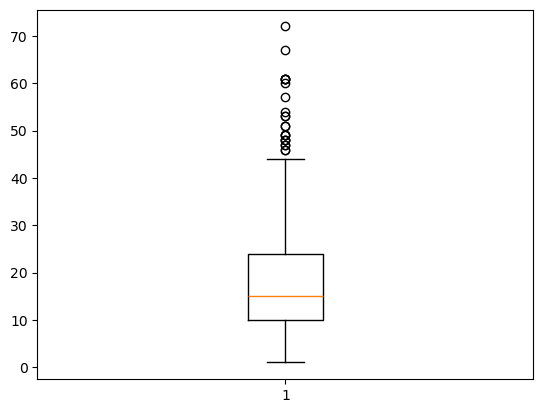

In [64]:
plt.boxplot([len(train_token) for train_token in all_train_tokens])

In [65]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes),
        )
    
    def forward(self, x, lengths=None):
        x = self.embedding(x)
        output, hidden = self.rnn(x)
        
        hidden = hidden[0]
        
        return self.fc(hidden[-1])

### Training the Model:

Unfortunately, immediately we see the drawbacks of RNNs as we encounter a vanshing gradient. The low movement of both the training loss and validation losses heavily suggest that the model is not learning much at all. Even by increasing the learning rate, the model still does not seem to learn as the losses incur multiple large spikes and will not converge properly. 

Parameters: 127,956


C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [RNN] Epoch 1/50 — Train: 1.2685 | Val: 1.6622
  [RNN] Epoch 10/50 — Train: 1.2656 | Val: 1.6698
  [RNN] Epoch 20/50 — Train: 1.2578 | Val: 1.6725
  [RNN] Epoch 30/50 — Train: 1.2469 | Val: 1.6840
  [RNN] Epoch 40/50 — Train: 1.2237 | Val: 1.7195
  [RNN] Epoch 50/50 — Train: 1.1476 | Val: 2.0379


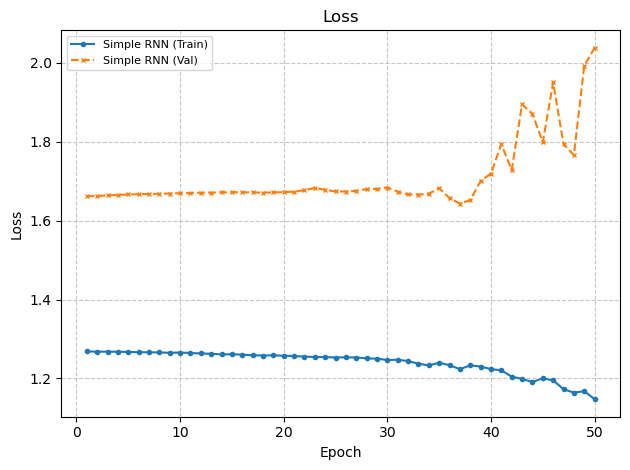

In [66]:
torch.manual_seed(67)
rnn_model = LSTMModel(
    VOCAB_SIZE, 64, 128, len(LABELS)
).to(device)

optimizer = optim.Adam(rnn_model.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)

print(f'Parameters: {sum(p.numel() for p in rnn_model.parameters()):,}')

all_results = {}
all_results['Simple RNN'] = run_experiment(
    rnn_model, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='RNN'
)

plot_experiments(all_results)

### Evaluating the Model:

The confusion matrices show that for every label, the model will almost always predict either True or False across all the samples. In every single label, the model predicts either only 1 for all 200 samples in the test data or only 0. This reinforces our notion that our model is not learning at all and is simply not learning at all. There does not seem to be a good intuitive reason for which labels are labelled all 1s or 0s. The model more often than not predicts all labels as 1 than it does 0, with 7 Labels all marked 0 (Appeal to Authority, Appeal to fear, Glittering Generalities, Name calling, Obfuscation, Red Herring, Reductio ad Hitlerum and Whataboutism) and all others as 1s. None of the labels in the groups have some common ground which connects them.

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0660      1.0000      0.1239           7      0.5050
Appeal to fear/preju         0.0538      0.7000      0.1000          10      0.3700
Black-and-white Fall         0.0300      0.4286      0.0561           7      0.4950
Causal Oversimplific         0.0152      0.6667      0.0296           3      0.3450
Doubt                        0.1805      0.8571      0.2981          28      0.4350
Exaggeration/Minimis         0.0968      0.6316      0.1678          19      0.4050
Flag-waving                  0.0303      1.0000      0.0588           6      0.0400
Glittering generalit         0.0796      0.8182      0.1452          11      0.4700
Loaded Language              0.5859      0.7500      0.6579         100      0.6100
Misrepresentation of         0.0078      1.0000      0.0155           1      0.3650
Name calling/Labelin         0.2727      0.6226      0.3793          53     

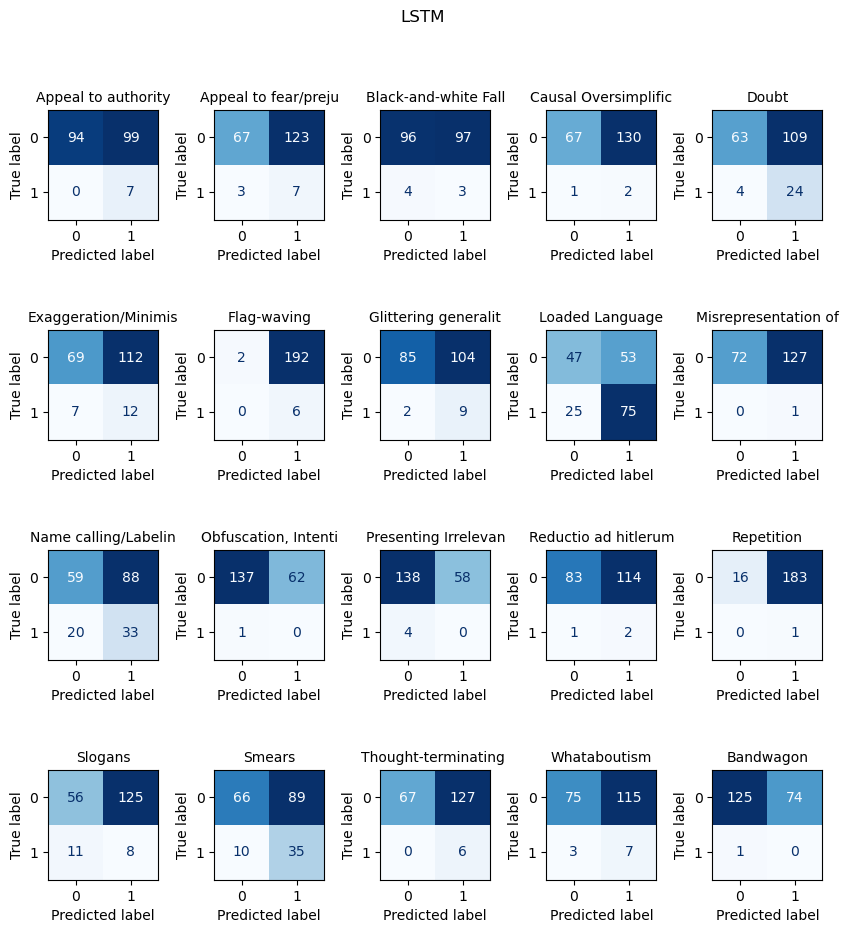

In [67]:
fig, report, accuracy = get_evaluation(rnn_model, test_loader, "LSTM")

view_report(report)
print(f"Mean Accuracy: {accuracy}")

### Experiment 1: Pre-trained Dense Embeddings

For my first experiment, I would like to try to introduce pretrained Dense embeddings into our model rather than create these embeddings ourselves. By using a pretrained embedding space, each token's semantic meaning can be represented in the vector space as deemed fit by some large training data. This should make the model "understand" the meaning of each meme better so that it can make better decisions.

### GloVe:

I decide to choose GloVe as my pretrained embedder of choice. Specifically the 6B version which has an embedding dimension of 50 and is pretrained on a corpus of wikipedia articles, I decide to use this version rather than the others which have higher embedding dimensions simply because it is the smallest model which should fit our needs for this small experiment. If we decide later to use this model, with the GloVe embeddings, I might use the one with the bigger embedding dimension to improve performance. Because the corpus is very general it should be able to capture almost all tokens that we throw at it. 

In [68]:
# Download GloVe 6B (50d — smallest version, ~66MB)
import urllib.request
import zipfile

GLOVE_DIM = 50
GLOVE_FILE = f'glove.6B.{GLOVE_DIM}d.txt'

if not os.path.exists(GLOVE_FILE):
    print('Downloading GloVe embeddings...')
    urllib.request.urlretrieve(
        'https://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip'
    )
    with zipfile.ZipFile('glove.6B.zip', 'r') as z:
        z.extract(GLOVE_FILE)
    print('Done.') 
else:
    print(f'{GLOVE_FILE} already exists.')

glove.6B.50d.txt already exists.


In [69]:
# Load GloVe into a dictionary
def load_glove(filepath, dim):
    embeddings = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            if len(vector) == dim:
                embeddings[word] = vector
    return embeddings

glove = load_glove(GLOVE_FILE, GLOVE_DIM)
print(f'Loaded {len(glove):,} GloVe vectors ({GLOVE_DIM}d)')

# Check coverage
covered = sum(1 for w in word_to_idx if w in glove)
print(f'Vocabulary coverage: {covered}/{len(word_to_idx)} ({covered/len(word_to_idx)*100:.1f}%)')

Loaded 400,000 GloVe vectors (50d)
Vocabulary coverage: 402/407 (98.8%)


In [70]:
def create_embedding_matrix(word_to_idx, glove, embed_dim):
    """Create an embedding matrix with GloVe vectors for known words."""
    matrix = np.zeros((len(word_to_idx), embed_dim))
    found, missing = 0, 0

    for word, idx in word_to_idx.items():
        if word in glove:
            matrix[idx] = glove[word]
            found += 1
        else:
            # Random initialisation for unknown words
            if word == "<PAD>":
                continue

            matrix[idx] = np.random.normal(scale=0.6, size=embed_dim)
            missing += 1

    print(f'Embedding matrix: {matrix.shape}')
    print(f'  Found in GloVe: {found}, Missing: {missing}')
    return torch.tensor(matrix, dtype=torch.float32)

embedding_matrix = create_embedding_matrix(word_to_idx, glove, GLOVE_DIM)

Embedding matrix: (407, 50)
  Found in GloVe: 402, Missing: 4


In [71]:
class DenseLSTM(nn.Module):
    def __init__(self, embedding_matrix, num_classes, hidden_dim, freeze_embeddings=True):
        super().__init__()
        
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=freeze_embeddings, padding_idx=PAD_IDX
        )

        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x, lengths=None):
        x = self.embedding(x)
        output, hidden = self.rnn(x)
        
        hidden = hidden[0]
        
        return self.fc(hidden[-1])

### Training the Model:

There seems to be an improvement, as the loss curves for both training and validation sets have begun moving, although much later at around epoch ~25. The model seems to achieve its best scores at around epoch ~42, before the model begins to overfit as training loss decreases while validation losses increase. Although there are some spikes in the validation losses which indicate improper convergence, a lower learning rate does not seem to help as the loss curves become stagnant again and the model is unable to train, possibly due to some local minima.

Parameters: 115,090


C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [DenseLSTM] Epoch 1/50 — Train: 1.2686 | Val: 1.6869
  [DenseLSTM] Epoch 10/50 — Train: 1.2664 | Val: 1.6928
  [DenseLSTM] Epoch 20/50 — Train: 1.2540 | Val: 1.6730
  [DenseLSTM] Epoch 30/50 — Train: 1.2172 | Val: 1.5791
  [DenseLSTM] Epoch 40/50 — Train: 1.1742 | Val: 1.7500
  [DenseLSTM] Epoch 50/50 — Train: 1.1437 | Val: 2.0757


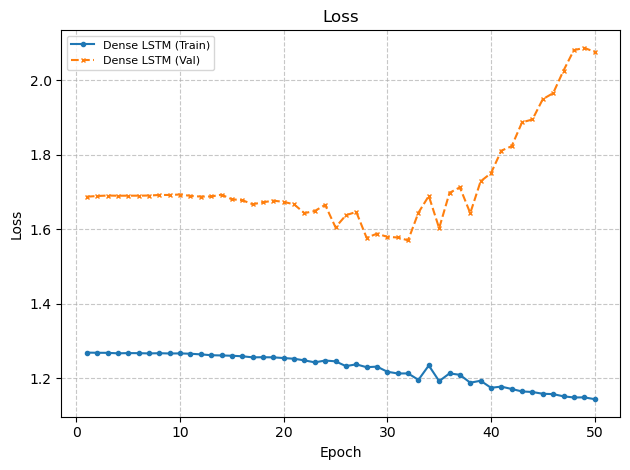

In [72]:
torch.manual_seed(67)
dense_lstm = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight = task1_label_weights)
optimizer = optim.Adam(dense_lstm.parameters(), lr=5e-4)

print(f'Parameters: {sum(p.numel() for p in dense_lstm.parameters()):,}')

all_results = {}
all_results['Dense LSTM'] = run_experiment(
    dense_lstm, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='DenseLSTM'
)

plot_experiments(all_results)

### Evaluating the Model

The model has begun to make varied predictions, the problem of having all labels be predicted as all 1s or all 0s is gone. The mean accuracy of the model is 0.68, with a macro recall of 0.48, precision of 0.12 and f1 of 0.15. The higher recall value and low precision value essentialy indicates that "the model predicts a lot of labels as positive. Of all the positive samples, we correctly classify almost a decent amount of them as positive. However, we also have many false-positives." Looking at the confusion matrices, we see that the model seems to struggle with flagging too many false-positives. 

I would like to bring up four specific labels' confusion matrices: Loaded Language, Name calling, Obfuscation and Red Herring (Presenting Irrelevant information). The former two represent labels who make up the majority of the label distribution, while the latter two represent labels who make up the minority of the label distribution. For the latter two, we see that the model has incredibly low precision values, while incorrectly labelling these labels as being positive, creating an abundance of false positives. The former two, does not have this problem. There appears to be a trend for minority labels to label most of the samples as being positive, creating many false positives. Reexamining our class weights, we see that for these minority classes, have their weights blown up. Red Herring and Bandwagon has weights of 687 and 343 respectively. I suspect that because of these high weight penalties, the model will falsely label most of these minority samples as true. 

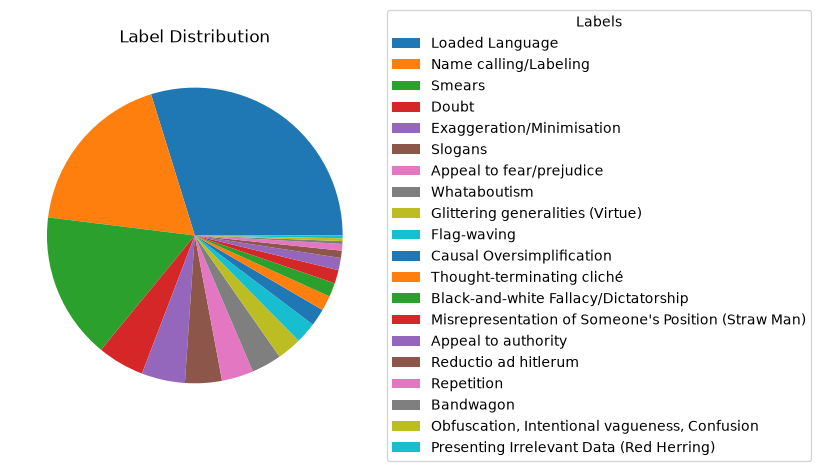
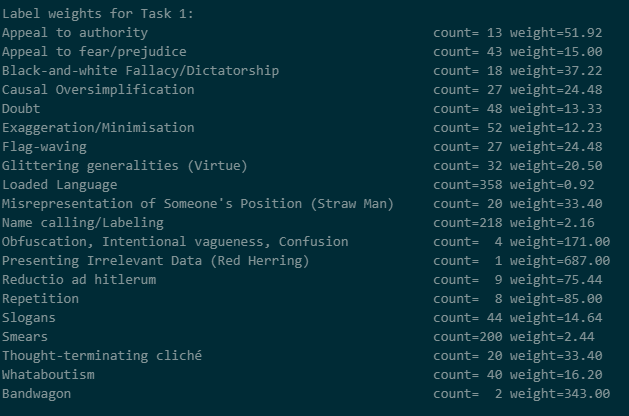

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0615      0.5714      0.1111           7      0.6800
Appeal to fear/preju         0.0964      0.8000      0.1720          10      0.6150
Black-and-white Fall         0.0465      0.5714      0.0860           7      0.5750
Causal Oversimplific         0.0260      0.6667      0.0500           3      0.6200
Doubt                        0.1688      0.4643      0.2476          28      0.6050
Exaggeration/Minimis         0.1286      0.4737      0.2022          19      0.6450
Flag-waving                  0.0465      0.6667      0.0870           6      0.5800
Glittering generalit         0.1000      0.6364      0.1728          11      0.6650
Loaded Language              0.6420      0.5200      0.5746         100      0.6150
Misrepresentation of         0.0000      0.0000      0.0000           1      0.6000
Name calling/Labelin         0.3038      0.4528      0.3636          53     

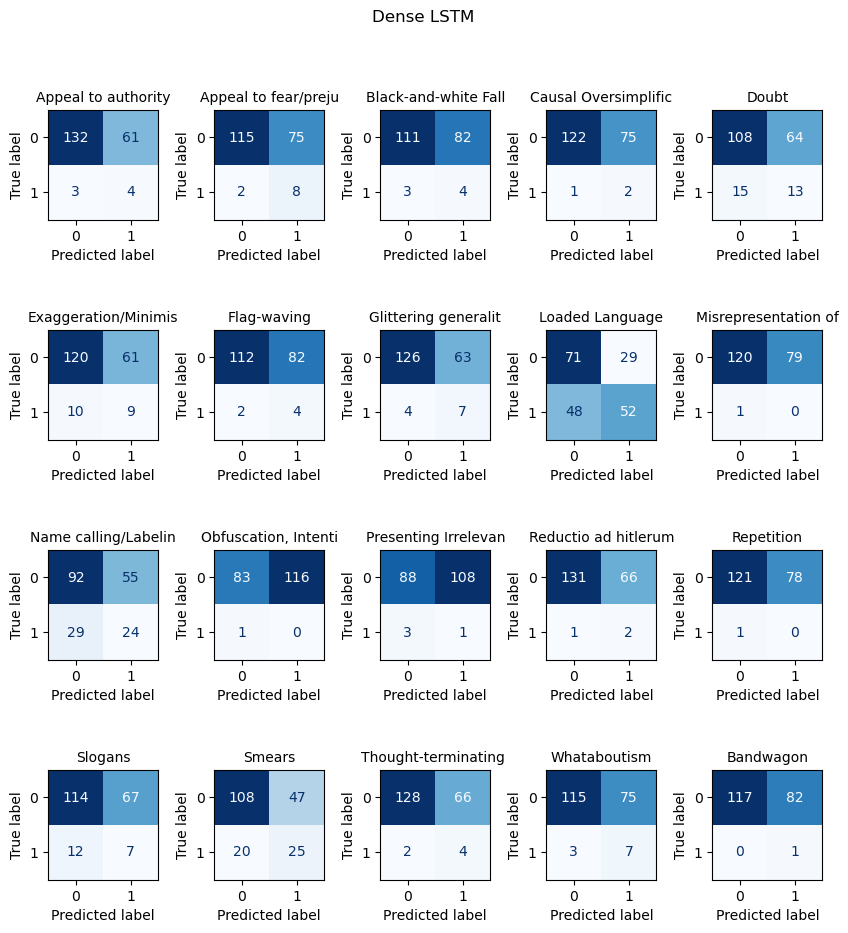

In [73]:
fig, report, accuracy = get_evaluation(dense_lstm, test_loader, "Dense LSTM", 0.5)

view_report(report)
print(f"Mean Accuracy: {accuracy}")

### Experiment 2: Fine Tuning Dense Embeddings (REJECTED)

Before addressing that issue, I would first also like to take time to see whether fine tuning the pretrained embeddings might also be worthwhile to do. The idea is that although we have a very general corpus for the trained embeddings, fine tuning the general embeddings of each token for our specific problem might make the model perform better.

### Training the Model:

The model's training is very similar to that of Experiment 1, not much of note is changed from those said in Experiment 1. 

Parameters: 115,090


C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [DenseLSTM] Epoch 1/50 — Train: 1.2686 | Val: 1.6869
  [DenseLSTM] Epoch 10/50 — Train: 1.2664 | Val: 1.6928
  [DenseLSTM] Epoch 20/50 — Train: 1.2536 | Val: 1.6724
  [DenseLSTM] Epoch 30/50 — Train: 1.2199 | Val: 1.6000
  [DenseLSTM] Epoch 40/50 — Train: 1.1723 | Val: 1.7661
  [DenseLSTM] Epoch 50/50 — Train: 1.2843 | Val: 1.8636


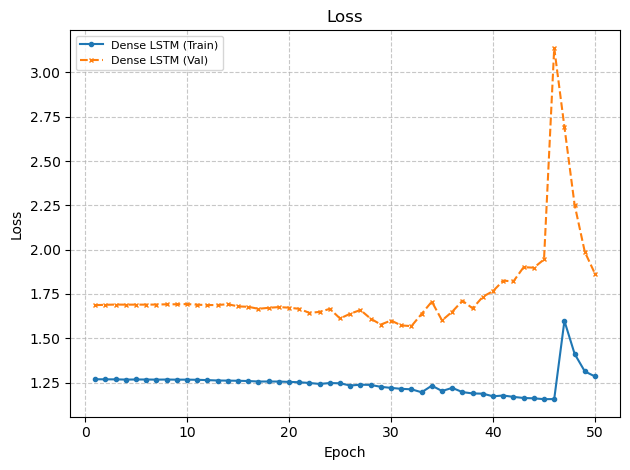

In [74]:
torch.manual_seed(67)
dense_lstm_fine_tune = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)
optimizer = optim.Adam(dense_lstm_fine_tune.parameters(), lr=5e-4)

print(f'Parameters: {sum(p.numel() for p in dense_lstm_fine_tune.parameters()):,}')

all_results = {}
all_results['Dense LSTM'] = run_experiment(
    dense_lstm_fine_tune, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='DenseLSTM'
)

plot_experiments(all_results)

### Evaluating the Model:

Between this model and Experiment 1, there are very minute differences between the two's performances. Although this model has a higher mean accuracy (0.63 vs 0.595) it has slightly lower precision, recall and f1-scores as well. Actually viewing the confusion matrices, we actually can see that the model makes significantly more mistakes than the previous one, only having higher accuracies in ~5 labels, while all others decrease. Because of this, I will reject this proposal and only rely on the pretrained embeddings from now on.

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0469      0.4286      0.0845           7      0.6750
Appeal to fear/preju         0.0941      0.8000      0.1684          10      0.6050
Black-and-white Fall         0.0440      0.5714      0.0816           7      0.5500
Causal Oversimplific         0.0244      0.6667      0.0471           3      0.5950
Doubt                        0.1585      0.4643      0.2364          28      0.5800
Exaggeration/Minimis         0.1370      0.5263      0.2174          19      0.6400
Flag-waving                  0.0435      0.6667      0.0816           6      0.5500
Glittering generalit         0.0946      0.6364      0.1647          11      0.6450
Loaded Language              0.6471      0.5500      0.5946         100      0.6250
Misrepresentation of         0.0000      0.0000      0.0000           1      0.5800
Name calling/Labelin         0.2892      0.4528      0.3529          53     

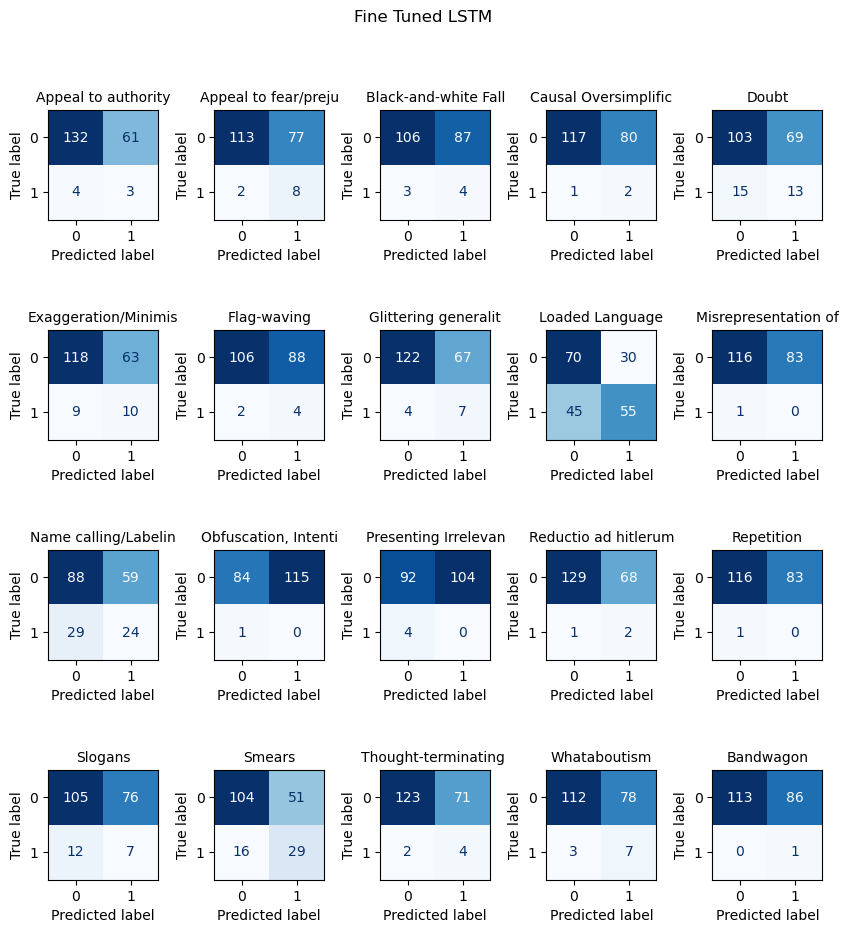

In [75]:
fig, report, accuracy = get_evaluation(dense_lstm_fine_tune, test_loader, "Fine Tuned LSTM")

view_report(report)
print(f"Mean Accuracy: {accuracy}")

### Experiment 3: Modify Class Weight (Rejected)

To address the problems brought up in Experiment 1, I decide to modify my label weights by testing different weight calculations. These include: square root transformation, log transformation and simple clamping. 

In [76]:
task1_sqrt_weights = torch.sqrt(task1_label_weights)

task1_log_weights = torch.tensor(
    [
        math.log1p(total / task1_label_counts[label])
        if task1_label_counts[label] > 0 else 1
        for label in LABELS
    ]
)

MAX_WEIGHT = 80
MIN_WEIGHT = 0
task1_clamped_weights = torch.clamp(task1_label_weights, min = MIN_WEIGHT, max = MAX_WEIGHT)

print('Sqrt Label weights for Task 1:')
for i, label in enumerate(LABELS):
    print(
        f"{label:<55} "
        f"count={task1_label_counts[label]:>3} "
        f"weight={task1_sqrt_weights[i].item():.2f}"
    )
    
print('Log Label weights for Task 1:')
for i, label in enumerate(LABELS):
    print(
        f"{label:<55} "
        f"count={task1_label_counts[label]:>3} "
        f"weight={task1_log_weights[i].item():.2f}"
    )

print('Clamped Label weights for Task 1:')
for i, label in enumerate(LABELS):
    print(
        f"{label:<55} "
        f"count={task1_label_counts[label]:>3} "
        f"weight={task1_clamped_weights[i].item():.2f}"
    )

Sqrt Label weights for Task 1:
Appeal to authority                                     count= 13 weight=7.21
Appeal to fear/prejudice                                count= 43 weight=3.87
Black-and-white Fallacy/Dictatorship                    count= 18 weight=6.10
Causal Oversimplification                               count= 27 weight=4.95
Doubt                                                   count= 48 weight=3.65
Exaggeration/Minimisation                               count= 52 weight=3.50
Flag-waving                                             count= 27 weight=4.95
Glittering generalities (Virtue)                        count= 32 weight=4.53
Loaded Language                                         count=358 weight=0.96
Misrepresentation of Someone's Position (Straw Man)     count= 20 weight=5.78
Name calling/Labeling                                   count=218 weight=1.47
Obfuscation, Intentional vagueness, Confusion           count=  4 weight=13.08
Presenting Irrelevant Data (Red 

Parameters: 115,090


C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [RNN Sqrt Weights] Epoch 1/50 — Train: 1.2686 | Val: 1.6869
  [RNN Sqrt Weights] Epoch 10/50 — Train: 1.2662 | Val: 1.6928
  [RNN Sqrt Weights] Epoch 20/50 — Train: 1.2426 | Val: 1.6272
  [RNN Sqrt Weights] Epoch 30/50 — Train: 1.2071 | Val: 1.5805
  [RNN Sqrt Weights] Epoch 40/50 — Train: 1.1699 | Val: 1.7016
  [RNN Sqrt Weights] Epoch 50/50 — Train: 1.2713 | Val: 1.7844


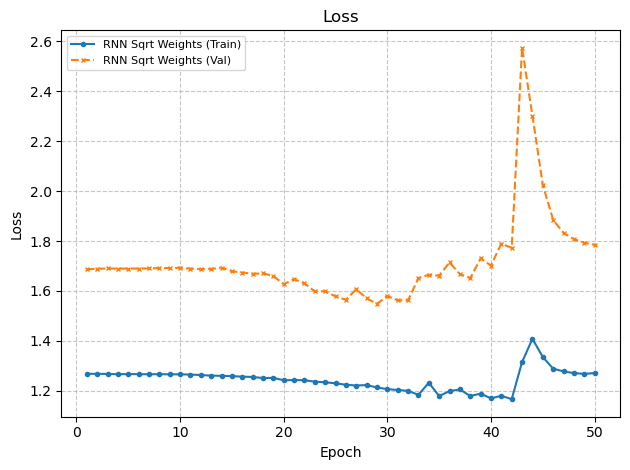

In [77]:
torch.manual_seed(67)
dense_lstm_sqrt_weight = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=True
).to(device)

optimizer = optim.Adam(dense_lstm_sqrt_weight.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)

print(f'Parameters: {sum(p.numel() for p in dense_lstm_sqrt_weight.parameters()):,}')

all_results = {}
all_results['RNN Sqrt Weights'] = run_experiment(
    dense_lstm_sqrt_weight, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='RNN Sqrt Weights'
)

plot_experiments(all_results)

Parameters: 115,090


C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [RNN Sqrt Weights] Epoch 1/50 — Train: 1.2686 | Val: 1.6869
  [RNN Sqrt Weights] Epoch 10/50 — Train: 1.2662 | Val: 1.6928
  [RNN Sqrt Weights] Epoch 20/50 — Train: 1.2426 | Val: 1.6272
  [RNN Sqrt Weights] Epoch 30/50 — Train: 1.2071 | Val: 1.5805
  [RNN Sqrt Weights] Epoch 40/50 — Train: 1.1699 | Val: 1.7016
  [RNN Sqrt Weights] Epoch 50/50 — Train: 1.2713 | Val: 1.7844


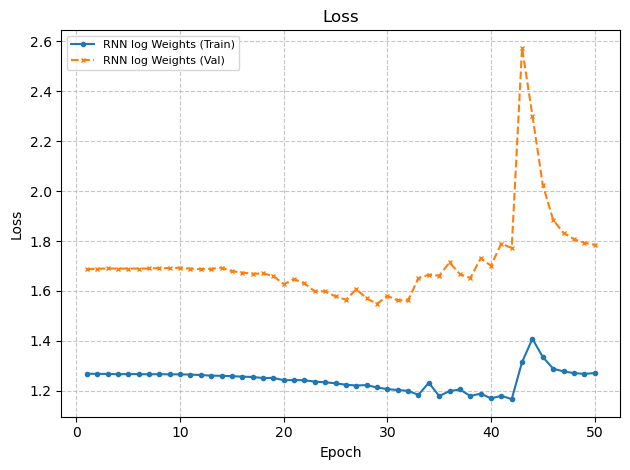

In [78]:
torch.manual_seed(67)
dense_lstm_log_weight = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=True
).to(device)

optimizer = optim.Adam(dense_lstm_log_weight.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)

print(f'Parameters: {sum(p.numel() for p in dense_lstm_log_weight.parameters()):,}')

all_results = {}
all_results['RNN log Weights'] = run_experiment(
    dense_lstm_log_weight, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='RNN Sqrt Weights'
)

plot_experiments(all_results)

Parameters: 115,090


C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [RNN Sqrt Weights] Epoch 1/50 — Train: 1.2686 | Val: 1.6869
  [RNN Sqrt Weights] Epoch 10/50 — Train: 1.2662 | Val: 1.6928
  [RNN Sqrt Weights] Epoch 20/50 — Train: 1.2426 | Val: 1.6272
  [RNN Sqrt Weights] Epoch 30/50 — Train: 1.2071 | Val: 1.5805
  [RNN Sqrt Weights] Epoch 40/50 — Train: 1.1699 | Val: 1.7016
  [RNN Sqrt Weights] Epoch 50/50 — Train: 1.2713 | Val: 1.7844


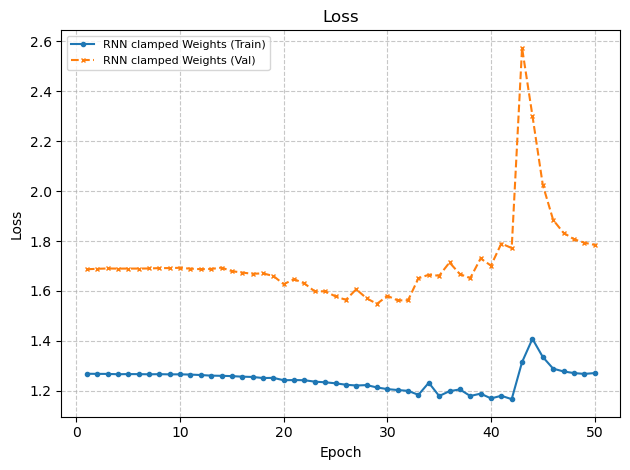

In [79]:
torch.manual_seed(67)
dense_lstm_clamped_weight = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=True
).to(device)

optimizer = optim.Adam(dense_lstm_clamped_weight.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)

print(f'Parameters: {sum(p.numel() for p in dense_lstm_clamped_weight.parameters()):,}')

all_results = {}
all_results['RNN clamped Weights'] = run_experiment(
    dense_lstm_clamped_weight, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='RNN Sqrt Weights'
)

plot_experiments(all_results)

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0615      0.5714      0.1111           7      0.6800
Appeal to fear/preju         0.0920      0.8000      0.1649          10      0.5950
Black-and-white Fall         0.0417      0.5714      0.0777           7      0.5250
Causal Oversimplific         0.0238      0.6667      0.0460           3      0.5850
Doubt                        0.1548      0.4643      0.2321          28      0.5700
Exaggeration/Minimis         0.1250      0.4737      0.1978          19      0.6350
Flag-waving                  0.0408      0.6667      0.0769           6      0.5200
Glittering generalit         0.0909      0.6364      0.1591          11      0.6300
Loaded Language              0.6471      0.5500      0.5946         100      0.6250
Misrepresentation of         0.0000      0.0000      0.0000           1      0.5750
Name calling/Labelin         0.2941      0.4717      0.3623          53     

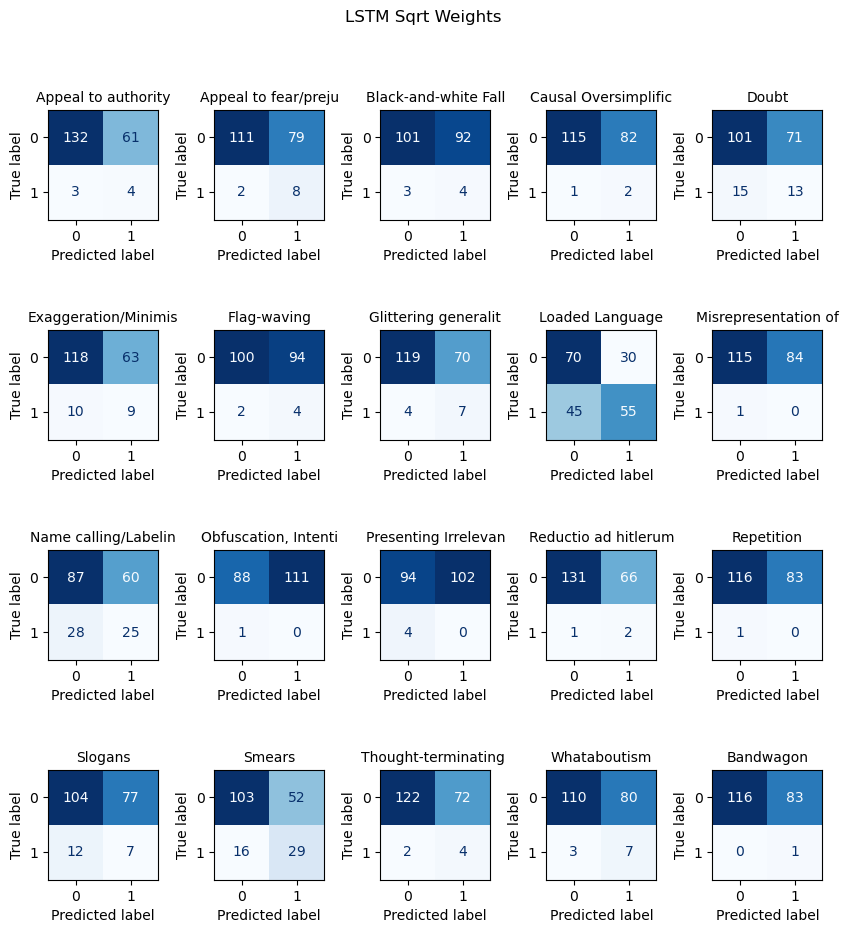

In [80]:
fig, report, accuracy = get_evaluation(dense_lstm_sqrt_weight, test_loader, "LSTM Sqrt Weights")

view_report(report)
print(f"Mean Accuracy: {accuracy}")

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0615      0.5714      0.1111           7      0.6800
Appeal to fear/preju         0.0920      0.8000      0.1649          10      0.5950
Black-and-white Fall         0.0417      0.5714      0.0777           7      0.5250
Causal Oversimplific         0.0238      0.6667      0.0460           3      0.5850
Doubt                        0.1548      0.4643      0.2321          28      0.5700
Exaggeration/Minimis         0.1250      0.4737      0.1978          19      0.6350
Flag-waving                  0.0408      0.6667      0.0769           6      0.5200
Glittering generalit         0.0909      0.6364      0.1591          11      0.6300
Loaded Language              0.6471      0.5500      0.5946         100      0.6250
Misrepresentation of         0.0000      0.0000      0.0000           1      0.5750
Name calling/Labelin         0.2941      0.4717      0.3623          53     

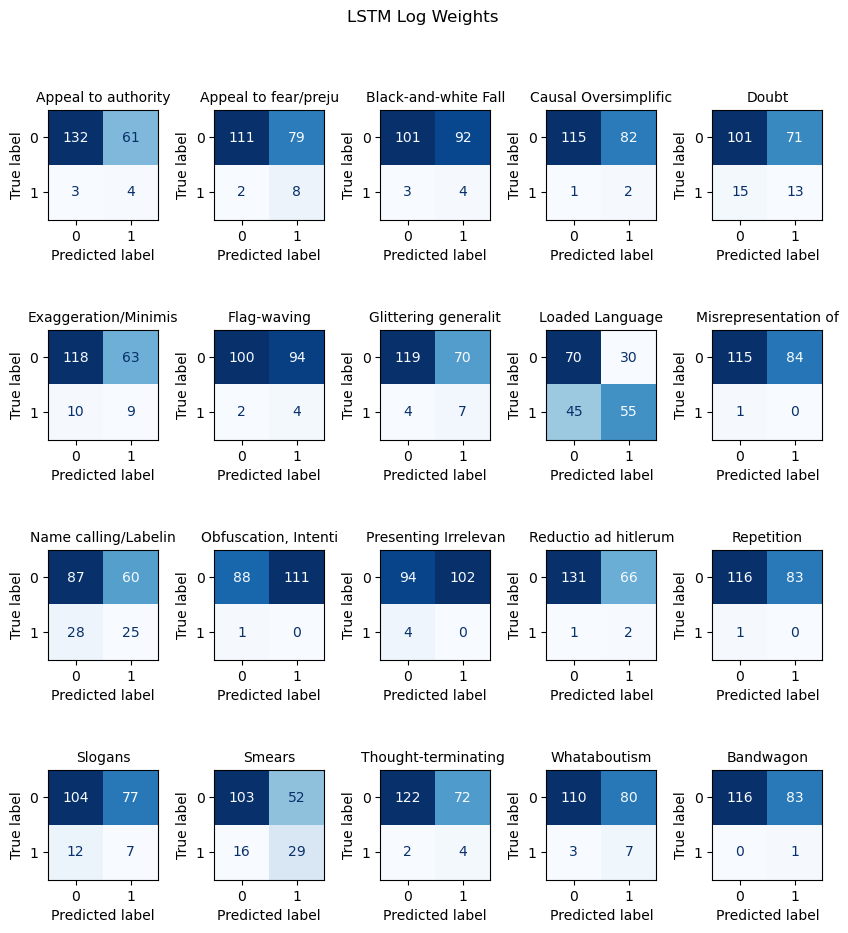

In [81]:
fig, report, accuracy = get_evaluation(dense_lstm_log_weight, test_loader, "LSTM Log Weights")

view_report(report)
print(f"Mean Accuracy: {accuracy}")

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0615      0.5714      0.1111           7      0.6800
Appeal to fear/preju         0.0920      0.8000      0.1649          10      0.5950
Black-and-white Fall         0.0417      0.5714      0.0777           7      0.5250
Causal Oversimplific         0.0238      0.6667      0.0460           3      0.5850
Doubt                        0.1548      0.4643      0.2321          28      0.5700
Exaggeration/Minimis         0.1250      0.4737      0.1978          19      0.6350
Flag-waving                  0.0408      0.6667      0.0769           6      0.5200
Glittering generalit         0.0909      0.6364      0.1591          11      0.6300
Loaded Language              0.6471      0.5500      0.5946         100      0.6250
Misrepresentation of         0.0000      0.0000      0.0000           1      0.5750
Name calling/Labelin         0.2941      0.4717      0.3623          53     

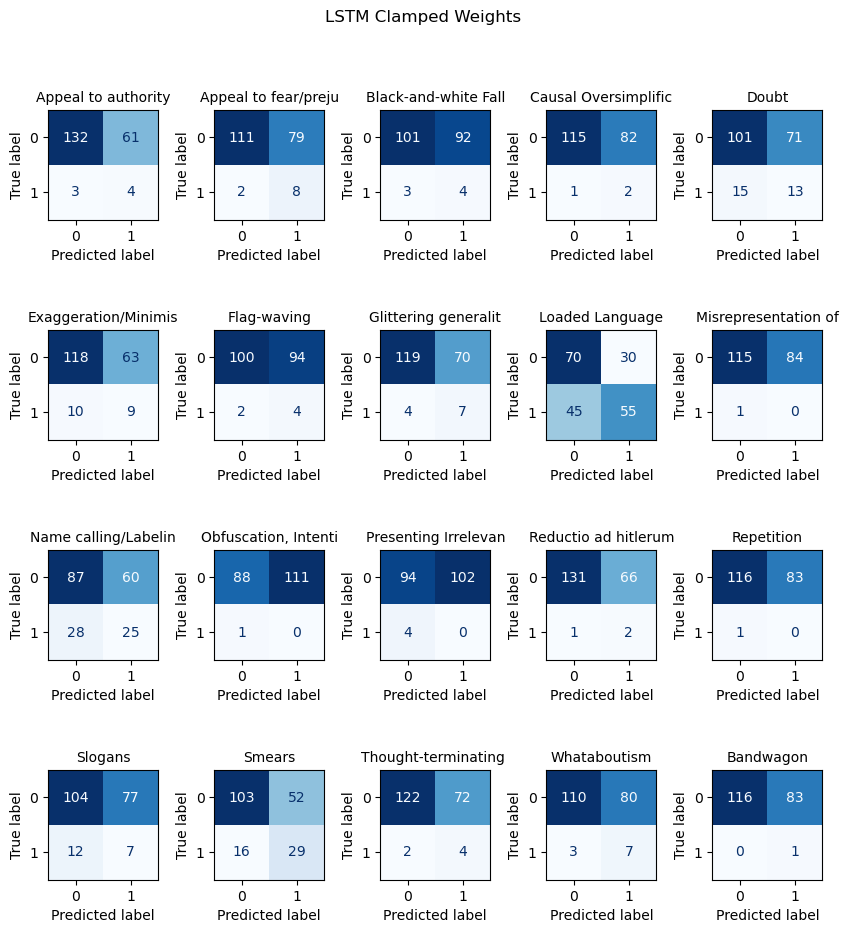

In [82]:
fig, report, accuracy = get_evaluation(dense_lstm_clamped_weight, test_loader, "LSTM Clamped Weights")

view_report(report)
print(f"Mean Accuracy: {accuracy}")

### Evaluating the Model(s):

None of the recalculated weights seem to improve our recall and f1-score. Although almost all of them yielded an increase in both accuracy and precision, the problem of too many false positives is still rampant. As such, I reject this proposal and will use the same label weights as before.

### Experiment 4: Adjusting Confidence Threshold

Another experiment I am thinking to solve the false-positive issues is by increasing the confidence threshold. Currently, by default we use probabilities above 0.5 to be a true label. However, the logic is that if we increase the minimum threshold, only samples where the model is extremely confident about its label will be flagged positive, lowering the number of positive labels, lowering the number of false positives. 

In [83]:
thresholds = [0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6]

precisions = []
recalls = []
f1_scores = []
accuracies = []

for threshold in thresholds:
    fig, report, acc = get_evaluation(
        dense_lstm,
        test_loader,
        f"LSTM Threshold {threshold:.2f}",
        threshold
    )

    precisions.append(report["macro avg"]["precision"])
    recalls.append(report["macro avg"]["recall"])
    f1_scores.append(report["macro avg"]["f1-score"])
    accuracies.append(acc)
    
    plt.close(fig)

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\logan\AppData\Local\Temp\ipykern

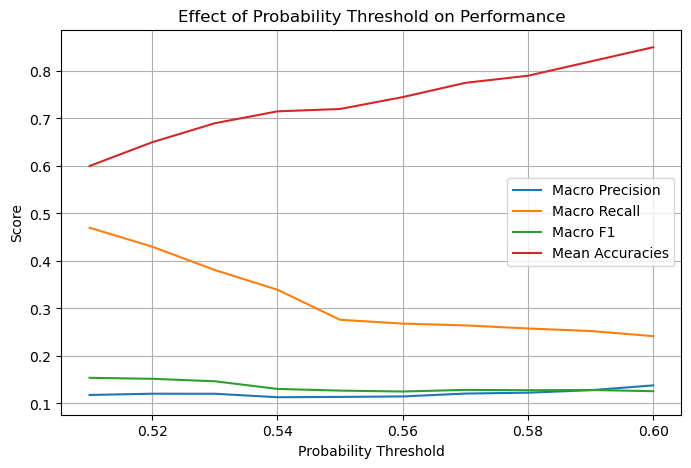

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions, label="Macro Precision")
plt.plot(thresholds, recalls, label="Macro Recall")
plt.plot(thresholds, f1_scores, label="Macro F1")
plt.plot(thresholds, accuracies, label="Mean Accuracies")

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Effect of Probability Threshold on Performance")
plt.legend()
plt.grid()
plt.show()

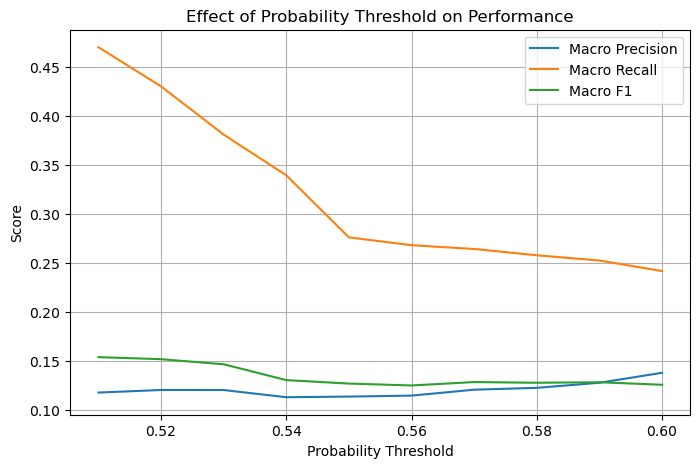

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions, label="Macro Precision")
plt.plot(thresholds, recalls, label="Macro Recall")
plt.plot(thresholds, f1_scores, label="Macro F1")

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Effect of Probability Threshold on Performance")
plt.legend()
plt.grid()
plt.show()

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\logan\anaconda3\Lib\site

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0000      0.0000      0.0000           7      0.8100
Appeal to fear/preju         0.0952      0.6000      0.1644          10      0.6950
Black-and-white Fall         0.0000      0.0000      0.0000           7      0.9650
Causal Oversimplific         0.0345      0.6667      0.0656           3      0.7150
Doubt                        0.1765      0.3214      0.2278          28      0.6950
Exaggeration/Minimis         0.1190      0.2632      0.1639          19      0.7450
Flag-waving                  0.0000      0.0000      0.0000           6      0.9700
Glittering generalit         0.1111      0.3636      0.1702          11      0.8050
Loaded Language              0.6885      0.4200      0.5217         100      0.6150
Misrepresentation of         0.0000      0.0000      0.0000           1      0.7250
Name calling/Labelin         0.3617      0.3208      0.3400          53     

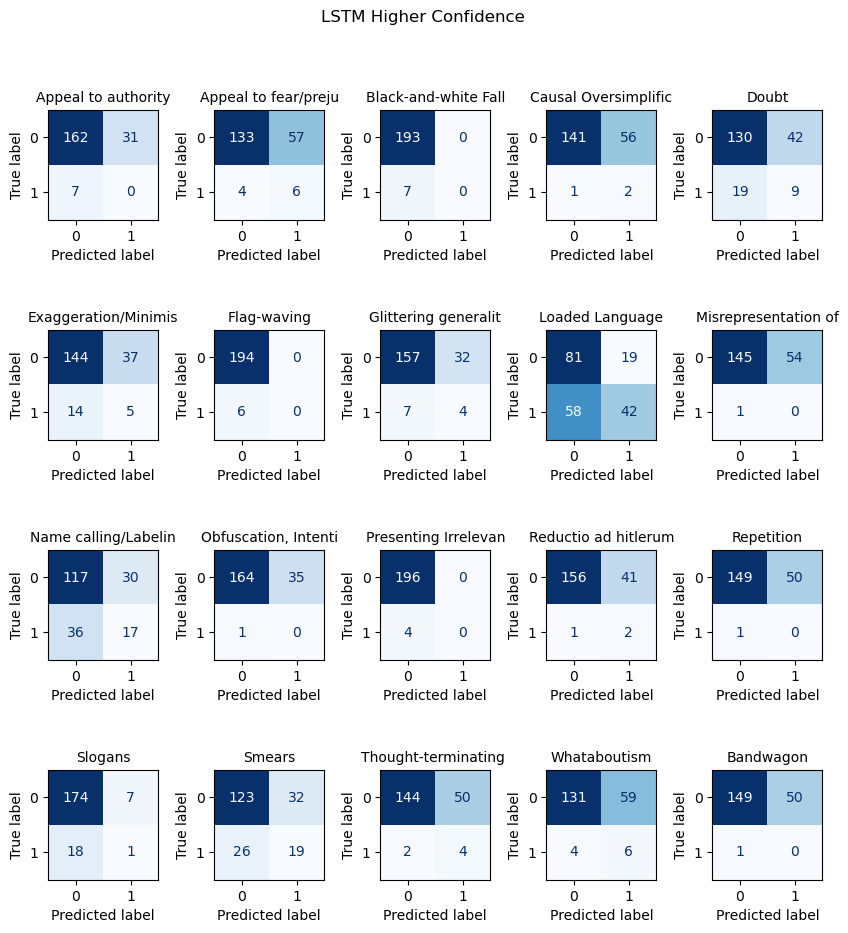

In [86]:
fig, report, accuracy = get_evaluation(dense_lstm, test_loader, "LSTM Higher Confidence", 0.56)

view_report(report)
print(f"Mean Accuracy: {accuracy}")

### Evaluating the Model(s):

By increasing the probability threshold, we are able to reduce the number of false positives, leading to increased precision (0.1320 vs 0.1117), however, this leads to an increase in false negatives as well, leading to reduce recall (0.3595 vs 0.5449). This leads to an increase in f1-score (0.1532 vs 1.1514) and accuracy (0.8 vs 0.595). The confusion matrices also reflect that we have succesfuly reduced the number of false positives. However, this comes at a cost of increasing the number of false negatives. 

What I also want to discuss is the effect of probability threshold on our metrics. All four metrics follow a similar trend, Mean Accuracy trends upwards with higher thresholds, as most of our labels are 0s, although a higher threshold results in more false negatives, the number of true negatives will increase faster, resulting in higher accuracies. Macro precision and f1 trend upwards before going down, because our current problem is the abundance of false-positives, increasing the threshold reduces the number of false positives, increasing precision, resulting in higher f1 scores until the moment where the number of false positives avoided becomes lower than number of false negatives created. Macro Recall on the other hand trends continously donwards as the number of labelled positive values reduces, so will the number of true positives. 

This granular control over all four metrics allows us to do a final fine-tuning of our model before releasing it. Allowing us to adjust, based on the model's needs.

### Experiment 5: Transformers (Rejected)

Finally, I try to improve the model by switching to using a Transformer Encoder architecture. To do this, I modify the existing LSTM architecture to introduce a positional encoding layer using sinusoidal encoding, as well as a TransformerEncoder layer. The idea is that we are encountering a vanishing gradient problem as a result of LSTM's inherent drawbacks. Transformers aim to fix that problem by using multi-headed attention layers such that all tokens are able to view each other all at once and update themselves all at once, resulting in no information loss. 

In [87]:
class DenseTransformer(nn.Module):
    def __init__(self, embedding_matrix, num_heads, num_layers, num_classes, max_len=MAX_LEN, freeze_embeddings=True):
        super().__init__()
        
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=freeze_embeddings, padding_idx=PAD_IDX
        )

        self.pos_encoding = PositionalEncoding(embed_dim, max_len)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embed_dim, num_classes)
        )
    
    def forward(self, x, lengths=None):
        # Create padding mask: True where padded
        pad_mask = (x == PAD_IDX)  # (batch, seq_len)
                
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        
        # Mean pooling (mask out padding)
        mask = (~pad_mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        
        return self.fc(x)

### Training the Model:

Unfortunately, we can see immediate signs of overfitting as val loss continuously trends upwards while training loss trends downwards. 

Parameters: 82,670


C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [DenseTransformer] Epoch 1/50 — Train: 1.3220 | Val: 1.7324
  [DenseTransformer] Epoch 10/50 — Train: 1.1857 | Val: 1.7065
  [DenseTransformer] Epoch 20/50 — Train: 1.0977 | Val: 1.7753
  [DenseTransformer] Epoch 30/50 — Train: 1.0045 | Val: 2.0548
  [DenseTransformer] Epoch 40/50 — Train: 0.9059 | Val: 2.4127
  [DenseTransformer] Epoch 50/50 — Train: 0.8510 | Val: 2.6413


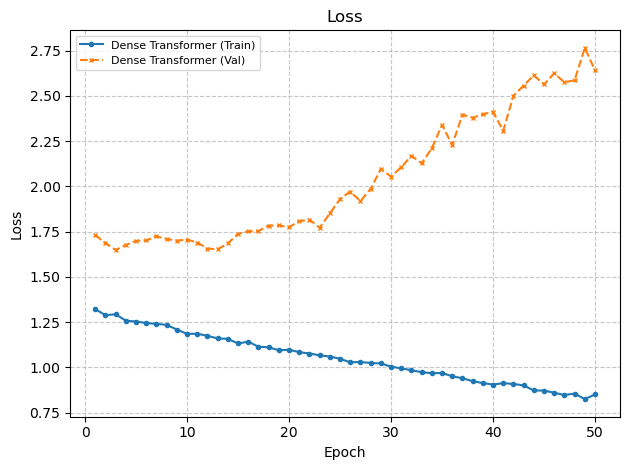

In [88]:
torch.manual_seed(67)
dense_tf = DenseTransformer(
    embedding_matrix=embedding_matrix,
    num_heads=2,
    num_layers=2,
    num_classes=len(LABELS),
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)
optimizer = optim.Adam(dense_tf.parameters(), lr=5e-4)

print(f'Parameters: {sum(p.numel() for p in dense_tf.parameters()):,}')

all_results = {}
all_results['Dense Transformer'] = run_experiment(
    dense_tf, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='DenseTransformer'
)

plot_experiments(all_results)

### Evaluating the Model:

This new model produces a lower precision (0.0769 vs 0.1320), recall (0.2542 vs 0.3595), f1-score (0.0589) and mean accuracy (0.215 vs 0.745). Looking at the confusion matrices, we that there is a massive increase in false positives which not even increasing the probability threshold can help (most prominently in Flag-waving, Causal Oversimplification and Bandwagon) and larger amounts of false negatives (especially in Loaded Language). 

What seems to happen is that the model has overfit to the training data, which is a common problem with training Transformers from scratch. Although LSTMs do have a drawback with vanishing gradients, it is possible that, due to the low lengths of each meme, it is not as harmful as expected. Instead, the Transformer's overfitting to the data outweighs the significance of any possible vanishing gradient problem, as such I decide to reject this model.

C:\Users\logan\AppData\Local\Temp\ipykernel_32936\2154028825.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\logan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\logan\anaconda3\Lib\site

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0000      0.0000      0.0000           7      0.9650
Appeal to fear/preju         0.0000      0.0000      0.0000          10      0.9400
Black-and-white Fall         0.0000      0.0000      0.0000           7      0.9500
Causal Oversimplific         0.0000      0.0000      0.0000           3      0.9850
Doubt                        0.0000      0.0000      0.0000          28      0.8400
Exaggeration/Minimis         0.0000      0.0000      0.0000          19      0.9000
Flag-waving                  0.0469      0.5000      0.0857           6      0.6800
Glittering generalit         0.1111      0.1818      0.1379          11      0.8750
Loaded Language              0.6667      0.3000      0.4138         100      0.5750
Misrepresentation of         0.0000      0.0000      0.0000           1      0.9950
Name calling/Labelin         0.3750      0.2830      0.3226          53     

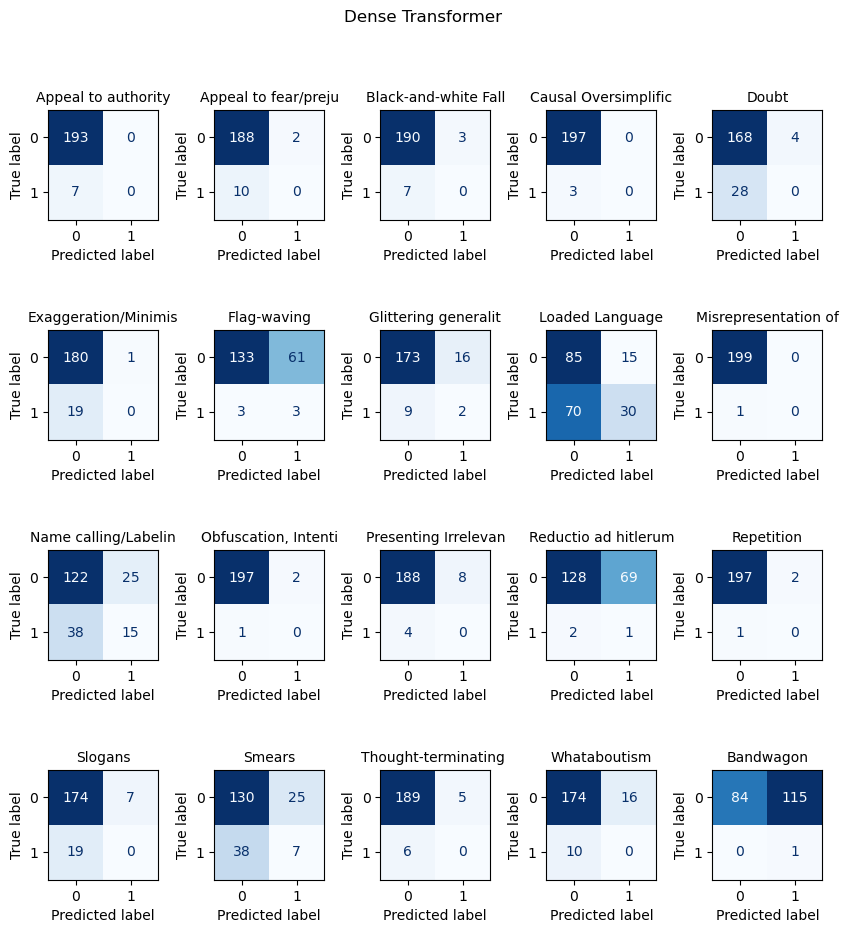

In [89]:
fig, report, accuracy = get_evaluation(dense_tf, test_loader, "Dense Transformer", 0.56)

view_report(report)
print(f"Mean Accuracy: {accuracy}")

### Pre-trained Transformer

Because of the issues of overfitting caused in Experiment 5, one way to rectify this problem is by using some pre-trained Transformer models which have been trained on some general corpus and will be less likely to overfit. To do this, I decide to test on using the distilbert-base-uncased pretrained Transformer, due to it being a widely used general Transformer. 

In [90]:
# Taken from Lab Week 8
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

test_sentences = [
    "I am unbelievably happy today!",
    "My son's first steps were amazing.",
    "I can't believe I won $100!",
]

for sent in test_sentences:
    simple_tokens = str(sent).lower().split()
    tf_tokens = tokenizer.tokenize(sent)
    print(f'Original:    "{sent}"')
    print(f'Simple:      {simple_tokens}')
    print(f'Transformer: {tf_tokens}')
    print()

Original:    "I am unbelievably happy today!"
Simple:      ['i', 'am', 'unbelievably', 'happy', 'today!']
Transformer: ['i', 'am', 'un', '##bel', '##ie', '##va', '##bly', 'happy', 'today', '!']

Original:    "My son's first steps were amazing."
Simple:      ['my', "son's", 'first', 'steps', 'were', 'amazing.']
Transformer: ['my', 'son', "'", 's', 'first', 'steps', 'were', 'amazing', '.']

Original:    "I can't believe I won $100!"
Simple:      ['i', "can't", 'believe', 'i', 'won', '$100!']
Transformer: ['i', 'can', "'", 't', 'believe', 'i', 'won', '$', '100', '!']



In [91]:
# Taken from Lab Week 8
encoded = tokenizer(
    "I am unbelievably happy",
    padding='max_length',
    truncation=True,
    max_length=12,
    return_tensors='pt'
)

print('Token IDs:      ', encoded['input_ids'][0].tolist())
print('Attention mask:  ', encoded['attention_mask'][0].tolist())
print('Decoded tokens:  ', tokenizer.convert_ids_to_tokens(encoded['input_ids'][0]))
print()
print('Notice:')
print('  - [CLS] at the start, [SEP] at the end')
print('  - "unbelievably" is split into subwords: un, ##believab, ##ly')
print('  - attention_mask is 1 for real tokens, 0 for padding')

Token IDs:       [101, 1045, 2572, 4895, 8671, 2666, 3567, 6321, 3407, 102, 0, 0]
Attention mask:   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Decoded tokens:   ['[CLS]', 'i', 'am', 'un', '##bel', '##ie', '##va', '##bly', 'happy', '[SEP]', '[PAD]', '[PAD]']

Notice:
  - [CLS] at the start, [SEP] at the end
  - "unbelievably" is split into subwords: un, ##believab, ##ly
  - attention_mask is 1 for real tokens, 0 for padding


In [100]:
# Taken from Lab Week 8
class HFDataset(Dataset):
    """Dataset compatible with Hugging Face transformer models."""
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.labels = labels
        self.encodings = tokenizer(
            texts,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }


task1_hf_train = HFDataset(train_set_task1["text"].to_list(), 
                           train_set_task1["label_encoded"], 
                           tokenizer,
                           MAX_LEN)
task1_hf_val = HFDataset(dev_set_task1["text"].to_list(), 
                           dev_set_task1["label_encoded"], 
                           tokenizer,
                           MAX_LEN)
task1_hf_test = HFDataset(test_set_task1["text"].to_list(), 
                           test_set_task1["label_encoded"], 
                           tokenizer,
                           MAX_LEN)

task1_hf_train_loader = DataLoader(task1_hf_train, batch_size=32, shuffle=True)
task1_hf_test_loader = DataLoader(task1_hf_test, batch_size=64, shuffle=False)
task1_hf_val_loader = DataLoader(task1_hf_val, batch_size=64, shuffle=False)

In [101]:
from transformers import AutoModelForSequenceClassification

distilbert = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(LABELS),
    token=False
)

for param in distilbert.distilbert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in distilbert.parameters() if p.requires_grad)
total = sum(p.numel() for p in distilbert.parameters())
print(f'Step 1: Linear Probing')
print(f'  Trainable: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)')

optimizer = optim.Adam(filter(lambda p: p.requires_grad, distilbert.parameters()), lr=1e-3)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)

all_results['DistilBERT (linear probe)'] = run_experiment(
    distilbert, optimizer, criterion, task1_hf_train_loader, task1_hf_val_loader,
    epochs=50, name='DistilBERT probe', tokenizer_mode=True
)

plot_experiments(all_results)

c:\Users\logan\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\logan\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install t

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors: peer closed connection without sending complete message body (received 17780405 bytes, expected 267954768)
Trying to resume download...


KeyboardInterrupt: 